## Setup PySpark Environment

First, we need to install `pyspark` and initialize a `SparkSession`.

In [10]:
# Install PySpark and findspark
!pip install pyspark
!pip install findspark

import findspark
findspark.init()

In [11]:
# Import SparkSession
from pyspark.sql import SparkSession

# Create a SparkSession
spark = SparkSession.builder \
    .appName("AirlineDelaysAnalysis") \
    .getOrCreate()

print("SparkSession created successfully!")

SparkSession created successfully!


## Load the Airline Delays Dataset

Now, let's load the airline delays data from your CSV file into a PySpark DataFrame. Please update the `file_path` with the actual path to your dataset.

In [18]:
file_path = "Airline_Delay_Cause (1).csv" # Update file_path to the correct file name

# Load the CSV file into a Spark DataFrame
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Display the schema and first few rows to verify loading
print("DataFrame Schema:")
df.printSchema()

print("\nFirst 5 rows of the DataFrame:")
df.show(5)

DataFrame Schema:
root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)


First 5 rows of the DataFrame:
+----+-----+-------+-------------+----

In [19]:
df.show(5)

+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        0|             0|     

In [21]:
df.columns

['year',
 'month',
 'carrier',
 'carrier_name',
 'airport',
 'airport_name',
 'arr_flights',
 'arr_del15',
 'carrier_ct',
 'weather_ct',
 'nas_ct',
 'security_ct',
 'late_aircraft_ct',
 'arr_cancelled',
 'arr_diverted',
 'arr_delay',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay']

In [31]:
from pyspark.sql.functions import col, sum, count, avg, round, month, year, expr, when, lit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from functools import reduce
from operator import add

## Question 1: How have overall flight delays changed over time?

Plot `arr_del15 / arr_flights` as a line chart by year and month.

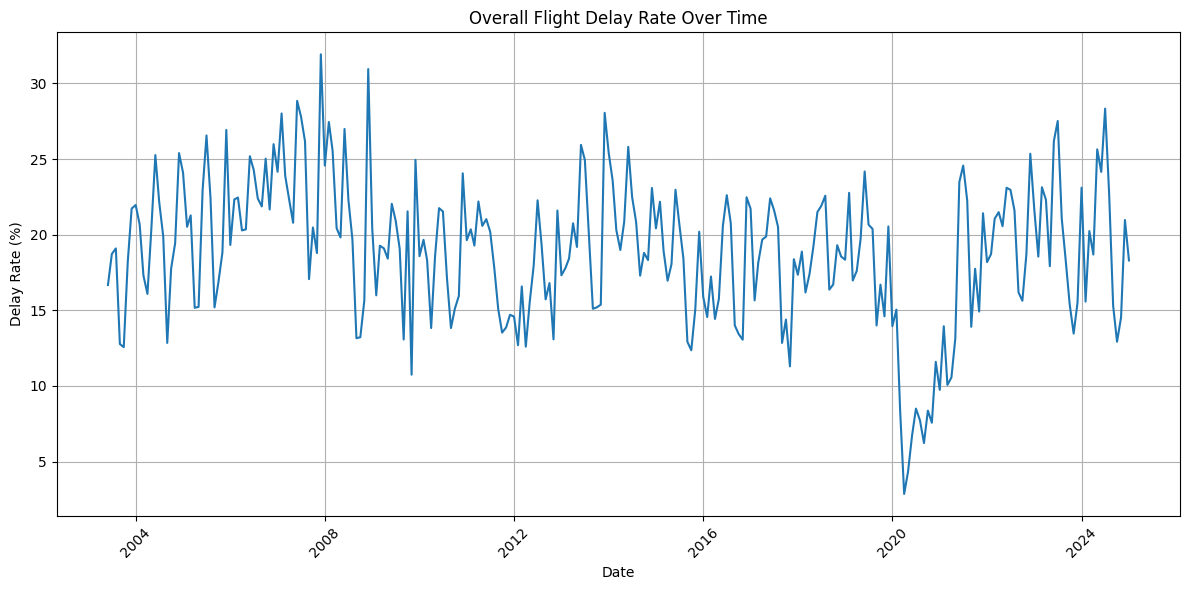

In [25]:
# Calculate monthly delay rate
monthly_delay_rate = df.groupBy("year", "month") \
    .agg(
        sum("arr_del15").alias("total_delays"),
        sum("arr_flights").alias("total_flights")
    ) \
    .withColumn("delay_rate", (col("total_delays") / col("total_flights")) * 100) \
    .orderBy("year", "month")

# Convert to Pandas for plotting
monthly_delay_rate_pd = monthly_delay_rate.toPandas()

# Create a date column for plotting
monthly_delay_rate_pd['date'] = pd.to_datetime(monthly_delay_rate_pd['year'].astype(str) + '-' + monthly_delay_rate_pd['month'].astype(str) + '-01')

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='delay_rate', data=monthly_delay_rate_pd)
plt.title('Overall Flight Delay Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Delay Rate (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 2: Which airlines have the highest percentage of delayed flights?

Create a bar chart of average delay rate per `carrier_name`.

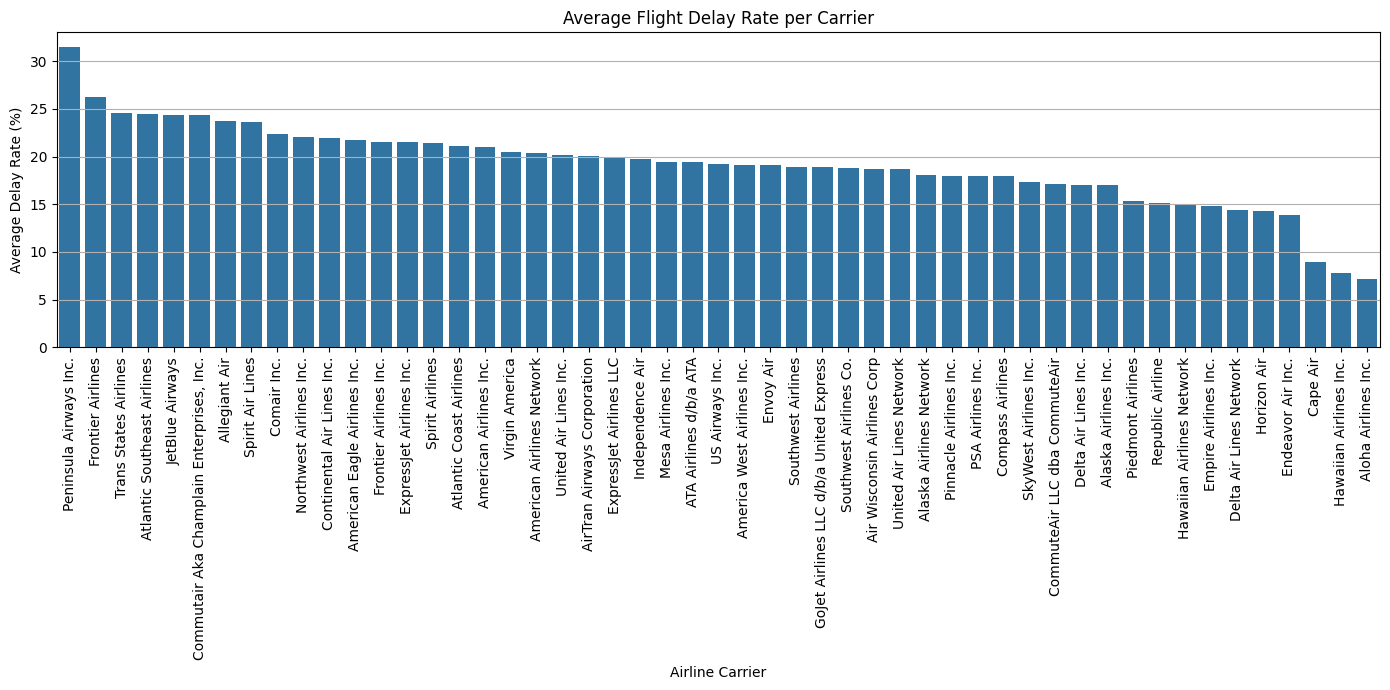

In [26]:
# Calculate average delay rate per carrier
carrier_delay_rate = df.groupBy("carrier_name") \
    .agg(
        sum("arr_del15").alias("total_delays"),
        sum("arr_flights").alias("total_flights")
    ) \
    .withColumn("delay_rate", (col("total_delays") / col("total_flights")) * 100) \
    .orderBy(col("delay_rate").desc())

# Convert to Pandas for plotting
carrier_delay_rate_pd = carrier_delay_rate.toPandas()

# Plotting
plt.figure(figsize=(14, 7))
sns.barplot(x='carrier_name', y='delay_rate', data=carrier_delay_rate_pd)
plt.title('Average Flight Delay Rate per Carrier')
plt.xlabel('Airline Carrier')
plt.ylabel('Average Delay Rate (%)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Question 3: Which airlines experience the most carrier‑caused delays?

Visualise `carrier_ct` (carrier-caused delay count) per airline.

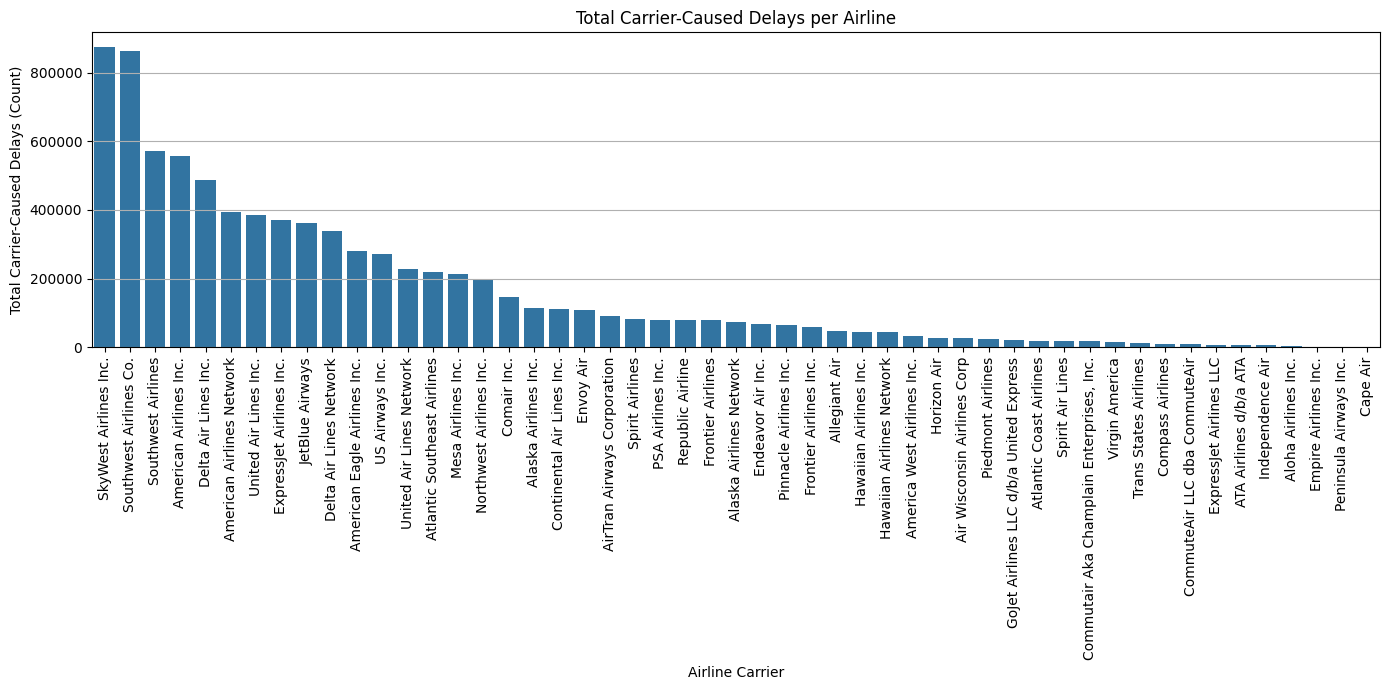

In [27]:
# Calculate total carrier-caused delays per airline
carrier_caused_delays = df.groupBy("carrier_name") \
    .agg(
        sum("carrier_ct").alias("total_carrier_caused_delays")
    ) \
    .orderBy(col("total_carrier_caused_delays").desc())

# Convert to Pandas for plotting
carrier_caused_delays_pd = carrier_caused_delays.toPandas()

# Plotting
plt.figure(figsize=(14, 7))
sns.barplot(x='carrier_name', y='total_carrier_caused_delays', data=carrier_caused_delays_pd)
plt.title('Total Carrier-Caused Delays per Airline')
plt.xlabel('Airline Carrier')
plt.ylabel('Total Carrier-Caused Delays (Count)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Question 4: Which airports have the highest delay rates?

Scatter or bar chart of delay rate vs airport, sorted by highest rates.

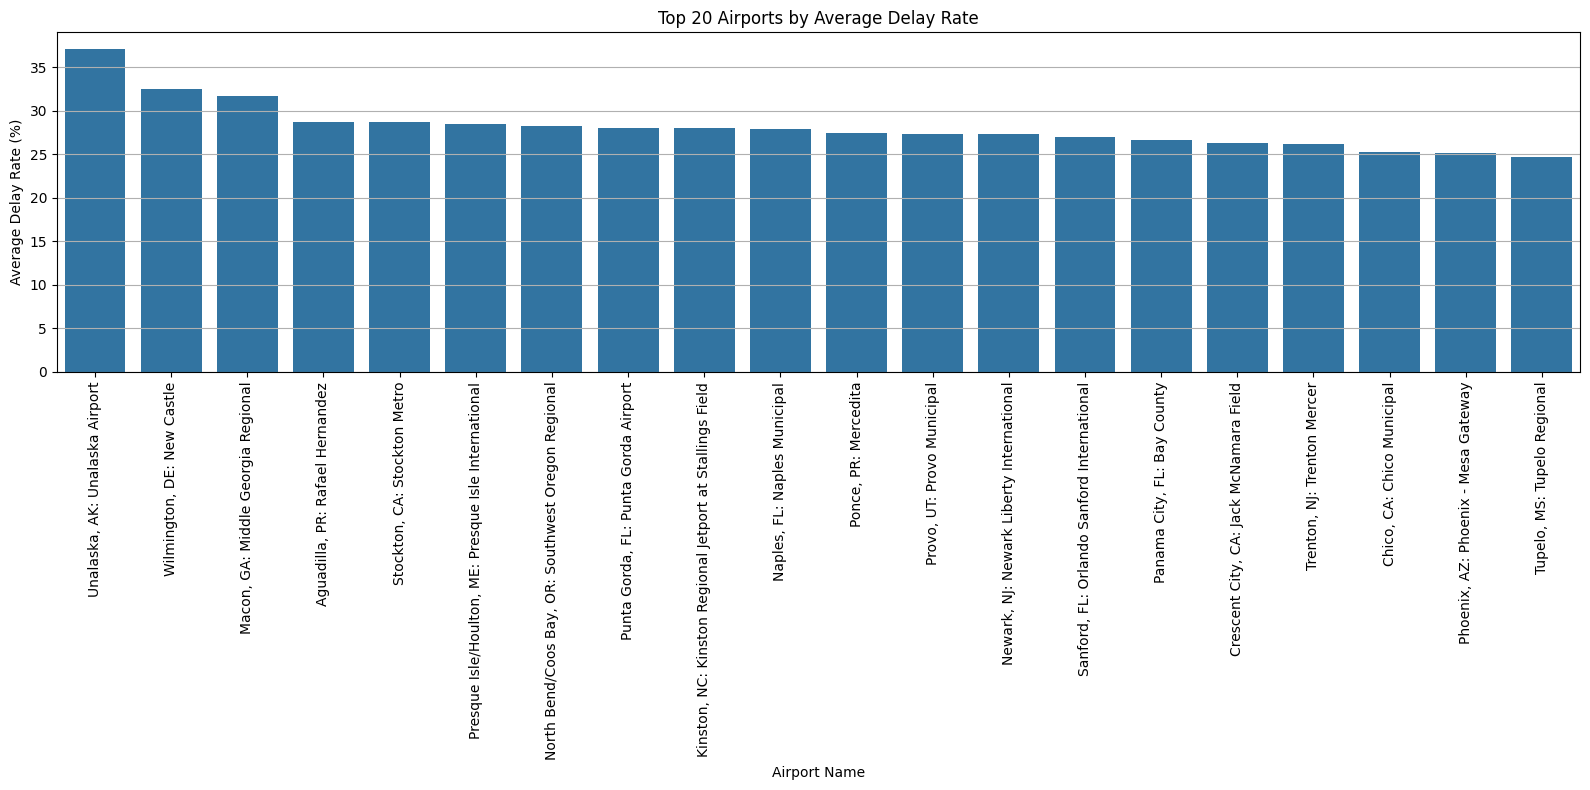

In [30]:
# Calculate average delay rate per airport
airport_delay_rate = df.groupBy("airport_name") \
    .agg(
        sum("arr_del15").alias("total_delays"),
        sum("arr_flights").alias("total_flights")
    ) \
    .withColumn("delay_rate", (col("total_delays") / col("total_flights")) * 100) \
    .filter(col("total_flights") > 1000) \
    .orderBy(col("delay_rate").desc())

# Convert to Pandas for plotting
airport_delay_rate_pd = airport_delay_rate.toPandas()

# Plotting (using a bar chart for better readability of airport names)
plt.figure(figsize=(16, 8))
sns.barplot(x='airport_name', y='delay_rate', data=airport_delay_rate_pd.head(20)) # Display top 20 airports
plt.title('Top 20 Airports by Average Delay Rate')
plt.xlabel('Airport Name')
plt.ylabel('Average Delay Rate (%)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Question 5: What are the dominant causes of delays across all flights?

Stacked bar chart: cause distribution percentage by year.

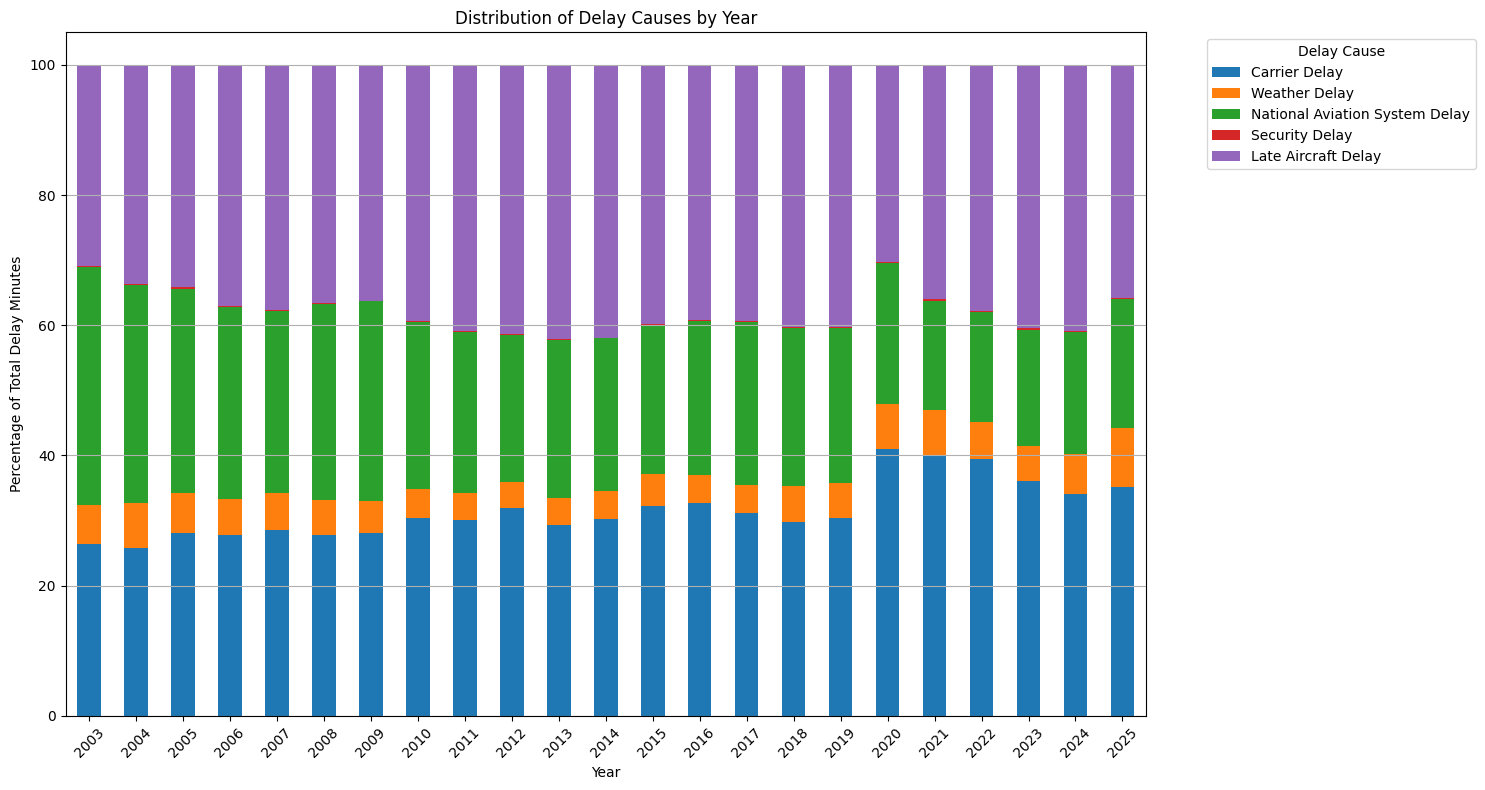

In [32]:
# Define delay cause columns
cause_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

# Calculate total delay minutes for each cause per year
yearly_delay_causes = df.groupBy("year") \
    .agg(*[sum(col).alias(col) for col in cause_cols]) \
    .orderBy("year")

# Calculate total delay minutes for all causes per year
yearly_delay_causes = yearly_delay_causes.withColumn(
    "total_delay_minutes", reduce(add, [col(c) for c in cause_cols])
)

# Calculate percentage of each delay cause
for col_name in cause_cols:
    yearly_delay_causes = yearly_delay_causes.withColumn(
        f"{col_name}_pct", (col(col_name) / col("total_delay_minutes")) * 100
    )

# Convert to Pandas for plotting
yearly_delay_causes_pd = yearly_delay_causes.toPandas()

# Select percentage columns for plotting
plot_cols = [f"{col}_pct" for col in cause_cols]
plot_data = yearly_delay_causes_pd[['year'] + plot_cols]

# Rename columns for better plot labels
plot_data.columns = ['year', 'Carrier Delay', 'Weather Delay', 'National Aviation System Delay', 'Security Delay', 'Late Aircraft Delay']

# Plotting stacked bar chart
plot_data.set_index('year').plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Distribution of Delay Causes by Year')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Delay Minutes')
plt.legend(title='Delay Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 6: How do causes vary by season?

Group by month; use a multi‑line chart showing counts for each cause. E.g., weather delays spike in winter; late aircraft delays spike in summer.

<Figure size 1400x700 with 0 Axes>

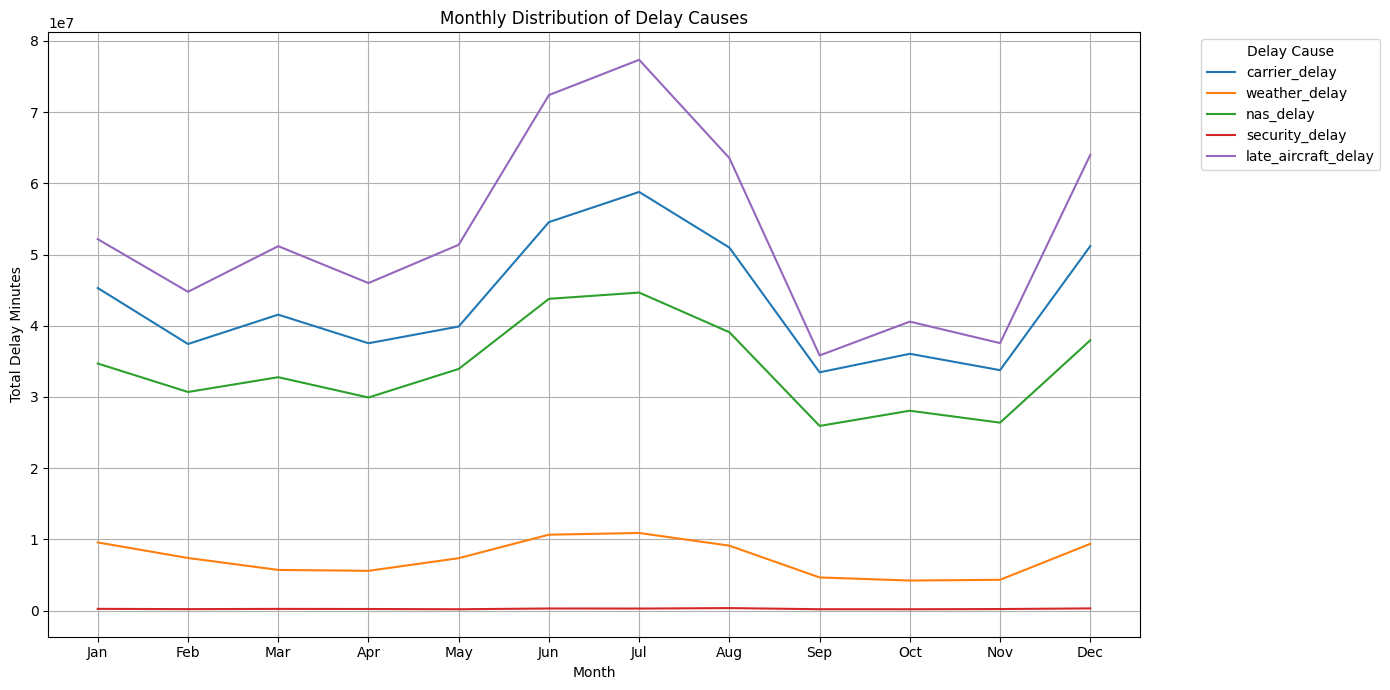

In [34]:
# Define delay cause columns
cause_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

# Calculate total delay minutes for each cause per month
monthly_delay_causes = df.groupBy("month") \
    .agg(*[sum(col).alias(col) for col in cause_cols]) \
    .orderBy("month")

# Convert to Pandas for plotting
monthly_delay_causes_pd = monthly_delay_causes.toPandas()

# Prepare data for multi-line plot
monthly_delay_causes_pd = monthly_delay_causes_pd.set_index('month')
monthly_delay_causes_pd = monthly_delay_causes_pd[cause_cols] # Select only cause columns

# Plotting multi-line chart
plt.figure(figsize=(14, 7))
monthly_delay_causes_pd.plot(kind='line', figsize=(14, 7))
plt.title('Monthly Distribution of Delay Causes')
plt.xlabel('Month')
plt.ylabel('Total Delay Minutes')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Delay Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Question 7: Which months have the highest and lowest delay percentages?

Use a line chart or boxplot grouped by month to reveal seasonality. Expect peaks around holidays and storms.

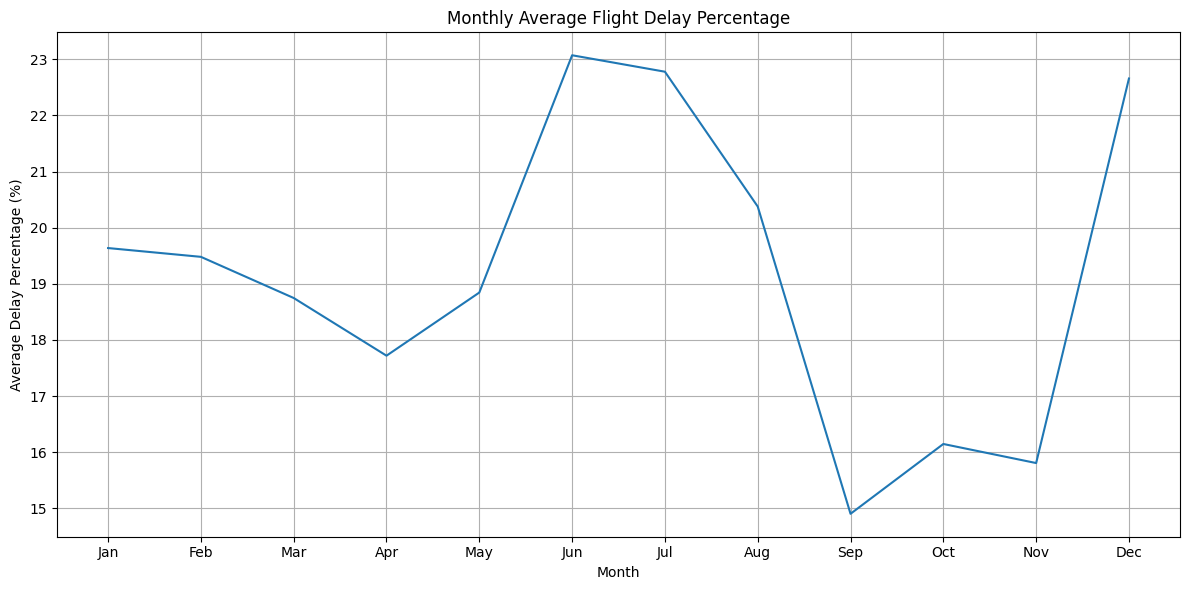

In [40]:
# Calculate monthly average delay percentage
monthly_delay_percentage = df.groupBy("month") \
    .agg(
        sum("arr_del15").alias("total_delays"),
        sum("arr_flights").alias("total_flights")
    ) \
    .withColumn("delay_percentage", (col("total_delays") / col("total_flights")) * 100) \
    .orderBy("month")

# Convert to Pandas for plotting
monthly_delay_percentage_pd = monthly_delay_percentage.toPandas()

# Plotting (Line chart)
plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='delay_percentage', data=monthly_delay_percentage_pd)
plt.title('Monthly Average Flight Delay Percentage')
plt.xlabel('Month')
plt.ylabel('Average Delay Percentage (%)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

# Alternatively, using a boxplot for more detailed seasonality (uncomment to use)
# plt.figure(figsize=(14, 7))
# sns.boxplot(x='month', y='delay_rate', data=monthly_delay_rate_pd) # Reusing monthly_delay_rate_pd from Q1 for consistency in yearly data spread
# plt.title('Monthly Delay Rate Distribution (Boxplot)')
# plt.xlabel('Month')
# plt.ylabel('Delay Rate (%)')
# plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
# plt.grid(True)
# plt.tight_layout()
# plt.show()